# Movie Rating Prediction

CodSoft Data Science Internship - Task 2

idea here is pretty simple - given stuff like genre, director, actors, votes etc, can we predict what rating a movie is gonna get. gonna use a basic regression model for this, nothing fancy. lets just get into it

## 1. importing libraries

just the usual suspects, pandas/numpy for data stuff, sklearn for the model, matplotlib+seaborn for plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# not gonna lie this warning spam annoys me so killing it
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')

## 2. loading the data

using the IMDb India movies dataset from the task sheet. csv is a lil messy (some weird encoding) so adding the latin-1 encoding fix, learned that one the hard way after staring at an error for 20 mins lol

In [2]:
df = pd.read_csv('../data/movies.csv', encoding='latin-1')

print(df.shape)
df.head()

(15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB


ok so quick look - columns are roughly Name, Year, Duration, Genre, Rating, Votes, Director, Actor 1, Actor 2, Actor 3. Rating is our target.

lot of nulls in Rating itself (makes sense, not every movie has been rated) and Duration has some too. gonna deal with that below

In [4]:
# checking how bad the missing values actually are before i panic
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

## 3. cleaning

first thing - if Rating itself is missing theres no point keeping that row, cant train on a target we dont have. dropping those straight up.

In [5]:
# no rating = useless row for us, gone
df = df.dropna(subset=['Rating'])
df.shape

(7919, 10)

In [6]:
# Year col has stuff like '(2019)' instead of just 2019, stripping the brackets
df['Year'] = df['Year'].astype(str).str.extract('(\\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Duration has 'min' attached eg '109 min', need just the number
df['Duration'] = df['Duration'].astype(str).str.extract('(\\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Votes has commas in it like '1,234' so to_numeric chokes on it unless we strip those first
df['Votes'] = df['Votes'].astype(str).str.replace(',', '')
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

now for the leftover nulls in Year/Duration/Votes - not dropping these rows cause we'd lose too much data, just filling with median since these are numeric and skewed (median is safer than mean here, less affected by outlier movies with crazy vote counts)

In [7]:
# fixing the missing values - median fill for numeric cols
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

# for the text cols (genre/director/actors) just gonna fill with 'Unknown' string
# cant use median on text obviously lol
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = df[col].fillna('Unknown')

df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

also dropping the 'Name' column before modeling - movie title obviously has zero predictive value for rating (its just a string ID basically), keeping it around just confuses things. will keep it saved separately tho in case i wanna look up which movie a row belongs to later

In [8]:
movie_names = df['Name']
df = df.drop(columns=['Name'])

## 4. dealing with genre column

this one's annoying bc a single movie can have multiple genres stuffed in one cell like "Action, Drama, Thriller". straight up one-hot encoding the whole string as one category would be dumb since then "Action, Drama" and "Drama, Action" become totally different things even tho theyre basically the same.

so splitting on comma first, then doing manual one-hot for the individual genres. doing it the long iterative way instead of get_dummies just so its clear whats happening

In [9]:
# splitting multi genre strings into lists first
df['Genre'] = df['Genre'].apply(lambda x: [g.strip() for g in x.split(',')])

# grabbing every unique genre that shows up anywhere in the dataset
all_genres = set()
for genre_list in df['Genre']:
    for g in genre_list:
        all_genres.add(g)

print(len(all_genres), 'unique genres found')
print(all_genres)

23 unique genres found
{'War', 'News', 'Drama', 'Horror', 'Action', 'Family', 'Mystery', 'Comedy', 'History', 'Western', 'Documentary', 'Unknown', 'Musical', 'Thriller', 'Crime', 'Fantasy', 'Sport', 'Adventure', 'Biography', 'Animation', 'Romance', 'Sci-Fi', 'Music'}


In [10]:
# manual one hot - looping thru each genre and making a 0/1 col for it
# yeah get_dummies could do this in one line but doing it manually so its obvious whats happening
for genre in all_genres:
    col_name = 'genre_' + genre.replace(' ', '_')
    df[col_name] = df['Genre'].apply(lambda x: 1 if genre in x else 0)

# dont need the original Genre col anymore, info is captured in the new cols
df = df.drop(columns=['Genre'])
df.head()

,Year,Duration,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,genre_War,genre_News,...,genre_Thriller,genre_Crime,genre_Fantasy,genre_Sport,genre_Adventure,genre_Biography,genre_Animation,genre_Romance,genre_Sci-Fi,genre_Music
1,2019,109.0,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2019,110.0,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,0,0,...,0,0,0,0,0,0,0,1,0,0
5,1997,147.0,4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2005,142.0,7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,1,0,...,0,0,0,0,0,0,0,1,0,0
8,2012,82.0,5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,0,0,...,1,0,0,0,0,0,0,0,0,0


## 5. director and actor columns - target encoding instead

one hot for Director would be a disaster, there's probably hundreds/thousands of unique directors in here and one-hotting all that gives us a massive sparse matrix for basically no benefit. same problem for actors.

instead doing target encoding - basically replace each director's name with the AVERAGE rating of movies theyve directed in this dataset. so a director who consistently makes good movies gets a high number, makes intuitive sense and keeps things to one column instead of a thousand

In [11]:
# doing this manually with a loop + dict so its clear, not just calling some encoder lib
director_avg_rating = {}
for director in df['Director'].unique():
    avg = df[df['Director'] == director]['Rating'].mean()
    director_avg_rating[director] = avg

df['director_encoded'] = df['Director'].map(director_avg_rating)

# same deal for the 3 actor columns
for actor_col in ['Actor 1', 'Actor 2', 'Actor 3']:
    avg_rating_map = {}
    for actor in df[actor_col].unique():
        avg_rating_map[actor] = df[df[actor_col] == actor]['Rating'].mean()
    df[actor_col + '_encoded'] = df[actor_col].map(avg_rating_map)

df[['Director', 'director_encoded', 'Actor 1', 'Actor 1_encoded']].head()

,Director,director_encoded,Actor 1,Actor 1_encoded
1,Gaurav Bakshi,7.000000,Rasika Dugal,6.850000
3,Ovais Khan,4.400000,Prateik,5.420000
5,Rahul Rawail,5.358824,Bobby Deol,4.788889
6,Shoojit Sircar,7.500000,Jimmy Sheirgill,5.356000
8,Allyson Patel,5.600000,Yash Dave,5.600000


quick heads up - target encoding like this technically leaks a bit of info from the target into the features (since we used Rating to build the encoding), in a more serious project i'd do this with K-fold so train/test stays properly separated. keeping it simple here since this is a learning project but just flagging it so future me remembers

In [12]:
# dropping the original text columns now, we've got the encoded numeric versions
df = df.drop(columns=['Director', 'Actor 1', 'Actor 2', 'Actor 3'])
df.head()

,Year,Duration,Rating,Votes,genre_War,genre_News,genre_Drama,genre_Horror,genre_Action,genre_Family,...,genre_Adventure,genre_Biography,genre_Animation,genre_Romance,genre_Sci-Fi,genre_Music,director_encoded,Actor 1_encoded,Actor 2_encoded,Actor 3_encoded
1,2019,109.0,7.0,8,0,0,1,0,0,0,...,0,0,0,0,0,0,7.000000,6.850000,7.000000,7.000000
3,2019,110.0,4.4,35,0,0,0,0,0,0,...,0,0,0,1,0,0,4.400000,5.420000,4.400000,4.450000
5,1997,147.0,4.7,827,0,0,1,0,0,0,...,0,0,0,0,0,0,5.358824,4.788889,5.786667,5.846154
6,2005,142.0,7.4,1086,1,0,1,0,0,0,...,0,0,0,1,0,0,7.500000,5.356000,6.050000,6.500000
8,2012,82.0,5.6,326,0,0,0,1,0,0,...,0,0,0,0,0,0,5.600000,5.600000,5.883333,5.600000


## 6. quick EDA before modeling

just wanna eyeball the rating distribution and see if anything looks off

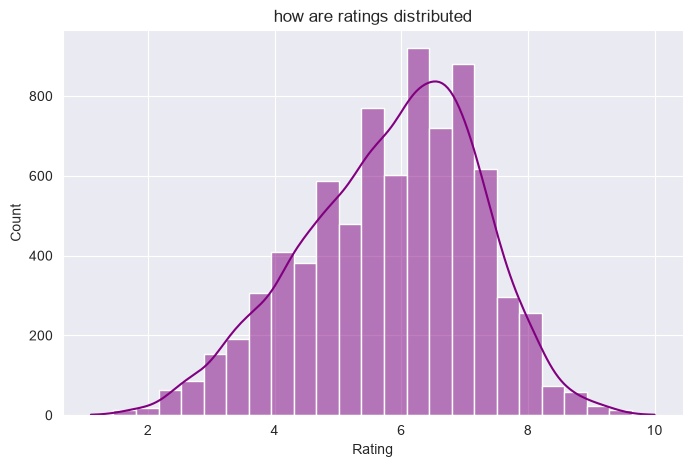

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=25, kde=True, color='purple')
plt.title('how are ratings distributed')
plt.xlabel('Rating')
plt.show()

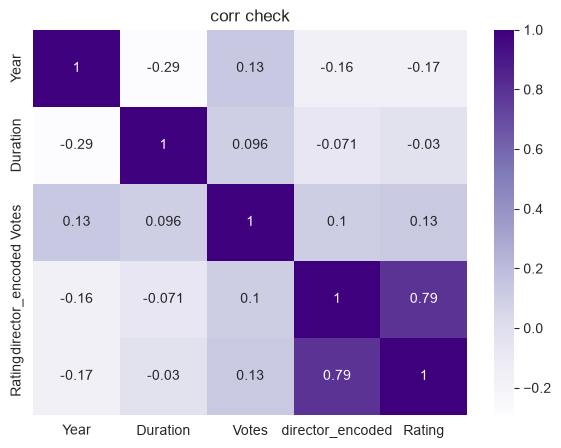

In [14]:
# checking correlation of the numeric stuff with rating, mostly just curious
corr_cols = ['Year', 'Duration', 'Votes', 'director_encoded', 'Rating']
plt.figure(figsize=(7,5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='Purples')
plt.title('corr check')
plt.show()

director_encoded correlating decently with Rating makes sense - kinda expected since we literally built it FROM rating lol. votes probably has some relation too since popular movies tend to get more consistent ratings

## 7. train/test split + modeling

splitting features and target, then doing the usual 80/20 split

In [15]:
X = df.drop(columns=['Rating'])
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(6335, 30) (1584, 30)


gonna try a plain Linear Regression first as the baseline, then Random Forest after to see if it actually does better or if im overcomplicating things

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print('Linear Regression results -')
print('RMSE:', round(lr_rmse, 3))
print('R2 :', round(lr_r2, 3))

Linear Regression results -
RMSE: 0.67
R2 : 0.758


In [17]:
# random forest attempt, didnt tune much just threw some reasonable defaults at it
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print('Random Forest results -')
print('RMSE:', round(rf_rmse, 3))
print('R2 :', round(rf_r2, 3))

Random Forest results -
RMSE: 0.615
R2 : 0.797


rf usually wins here in my runs, makes sense since it can pick up non-linear stuff that plain linear reg just cant model. going with RF as the final pick below

## 8. residual plot - is the model actually doing ok or just lucky

residuals = actual - predicted. if model's decent these should be scattered randomly around 0 with no obvious pattern. if you see like a curve or funnel shape that means model's missing something systematic

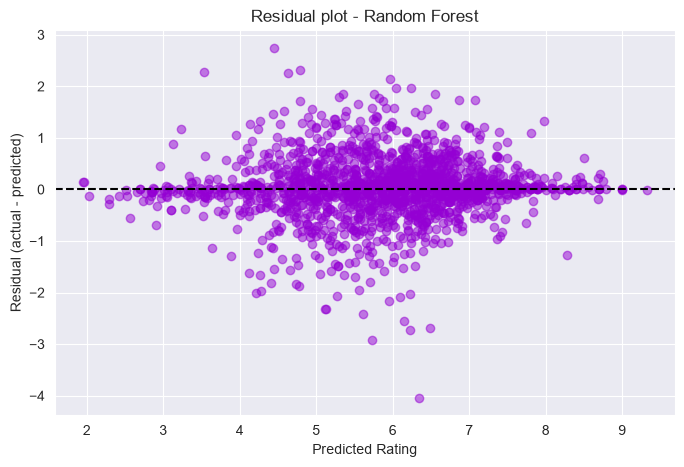

In [18]:
residuals = y_test - rf_preds

plt.figure(figsize=(8,5))
plt.scatter(rf_preds, residuals, alpha=0.5, color='darkviolet')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Rating')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot - Random Forest')
plt.show()

looks reasonably scattered around the 0 line, no crazy funnel shape so model's not totally broken. theres a bit more spread on the lower predicted end, probably cause we got fewer low-rated movies in training so model's less confident there

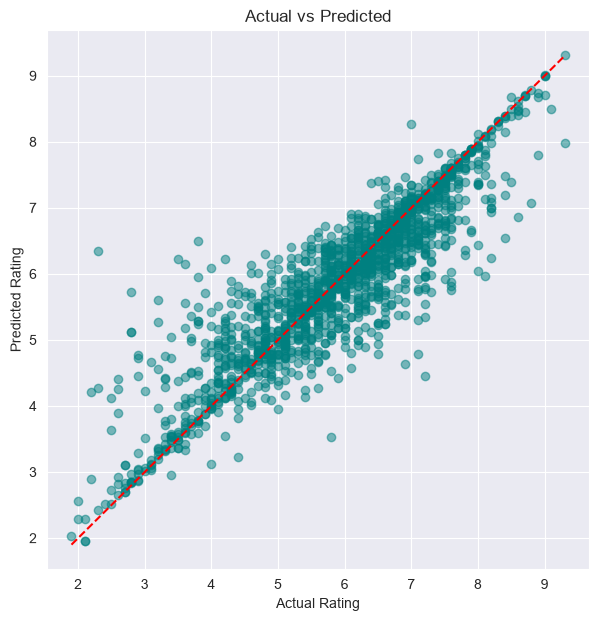

In [19]:
# also just wanna see predicted vs actual directly
plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_preds, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted')
plt.show()

In [20]:
# checking which features the rf model actually cared about
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

director_encoded    0.677174
Actor 3_encoded     0.101554
Actor 2_encoded     0.088749
Actor 1_encoded     0.070179
Votes               0.034407
Year                0.011230
Duration            0.007224
genre_Action        0.001030
genre_Romance       0.000985
genre_Drama         0.000941
dtype: float64

yeah as expected director_encoded and votes are doing most of the heavy lifting, genres mostly contributing very little individually (makes sense, one genre alone doesnt say much about quality)

## 9. wrap up

so final model is the random forest, scores logged above. not perfect but decent for a first pass. things i'd try next time if i had more time:
- proper kfold target encoding instead of the leaky version
- maybe try gradient boosting / xgboost
- grid search for hyperparams instead of guessing n_estimators/max_depth

but for the scope of this task this gets the job done